<a href="https://colab.research.google.com/github/zydanne-costa/Ondas_ADCP_SCO_Mar_Nov_2025/blob/main/Vento_ERA5_CHU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Caminhos de importação


março /content/drive/MyDrive/Ondas/VENTO_ERA5/Vento_SCO_ERAS5_MAR_2025.csv


abril /content/drive/MyDrive/Ondas/VENTO_ERA5/Vento_SCO_ERAS5_ABR_2025.csv

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
# importando o mes de marco
file_path = '/content/drive/MyDrive/Ondas/VENTO_ERA5/Vento_SCO_ERAS5_MAR_2025.csv'
df_mar = pd.read_csv(file_path, sep=';')

# abril
file_path = '/content/drive/MyDrive/Ondas/VENTO_ERA5/Vento_SCO_ERAS5_ABR_2025.csv'
df_abr = pd.read_csv(file_path, sep=';')

In [3]:
# criando do df de marco
df_wind_mar = pd.DataFrame()
df_wind_mar['datetime'] = pd.to_datetime(df_mar['datetime'], format='%d/%m/%Y %H:%M')
df_wind_mar['dir_deg'] = df_mar['dir_deg'].round(1)
df_wind_mar['vel_ms'] = df_mar['vel_m_s'].round(2)

# abril
df_wind_abr = pd.DataFrame()
df_wind_abr['datetime'] = pd.to_datetime(df_abr['datetime'], format='%d/%m/%Y %H:%M')
df_wind_abr['dir_deg'] = df_abr['dir_deg'].round(1)
df_wind_abr['vel_ms'] = df_abr['vel_m_s'].round(2)


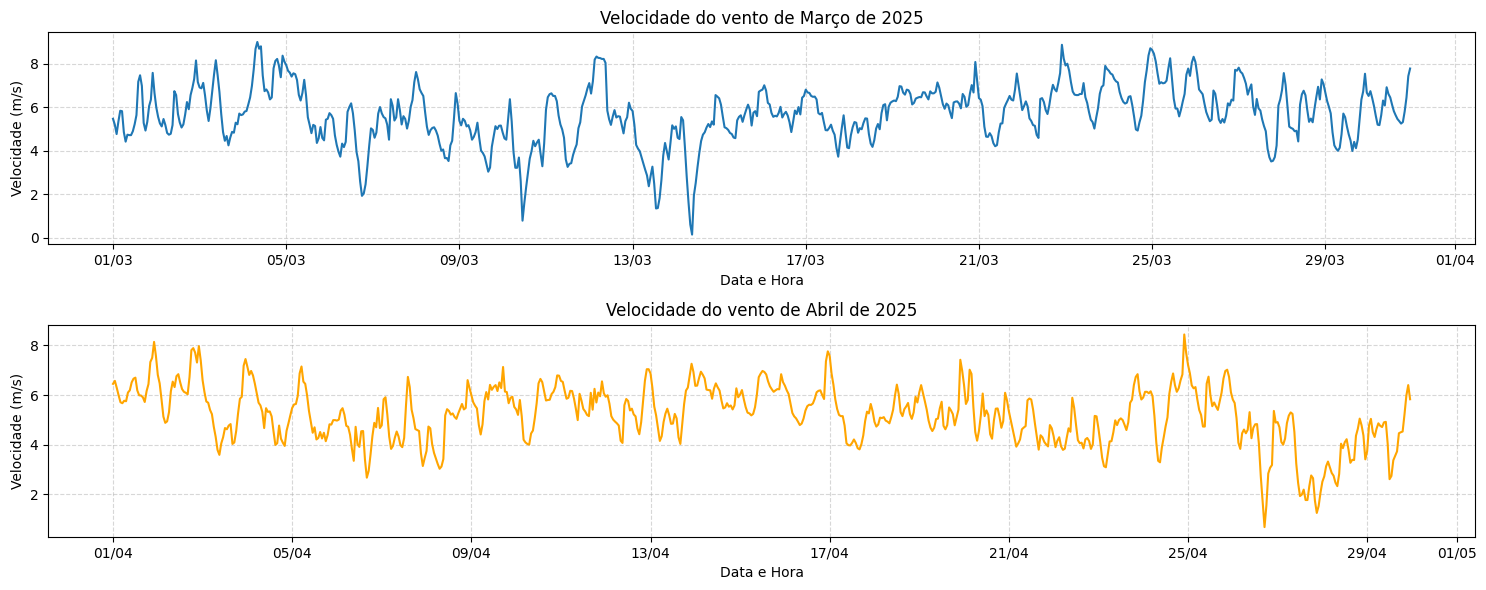

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

plt.figure(figsize=(15, 6))

# plotando as velocidades de cada mês
# marco
ax1 = plt.subplot(2, 1, 1) # 1 linha, 2 colunas, 1o plot
sns.lineplot(x='datetime', y='vel_ms', data=df_wind_mar, ax=ax1)
plt.title('Velocidade do vento de Março de 2025')
plt.xlabel('Data e Hora')
plt.ylabel('Velocidade (m/s)')
plt.xticks()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m')) # formato que a data ira aparecer no plt
plt.grid(True, linestyle='--', alpha=0.5)
# marco
ax2 = plt.subplot(2, 1, 2) # 1 linha, 2 colunas, 1o plot
sns.lineplot(x='datetime', y='vel_ms', data=df_wind_abr, color='orange', ax=ax2)
plt.title('Velocidade do vento de Abril de 2025')
plt.xlabel('Data e Hora')
plt.ylabel('Velocidade (m/s)')
plt.xticks()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m')) # formato que a data ira aparecer no plt
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
df_chu = pd.DataFrame({
    'datetime': pd.concat([df_wind_mar['datetime'], df_wind_abr['datetime']], ignore_index=True),
    'vel_ms': pd.concat([df_wind_mar['vel_ms'], df_wind_abr['vel_ms']], ignore_index=True),
    'dir_deg': pd.concat([df_wind_mar['dir_deg'], df_wind_abr['dir_deg']], ignore_index=True)
})


display(df_chu.head())

,datetime,vel_ms,dir_deg
0,2025-03-01 00:00:00,5.47,80.0
1,2025-03-01 01:00:00,5.20,81.2
2,2025-03-01 02:00:00,4.77,73.6
3,2025-03-01 03:00:00,5.35,73.7
4,2025-03-01 04:00:00,5.84,82.3


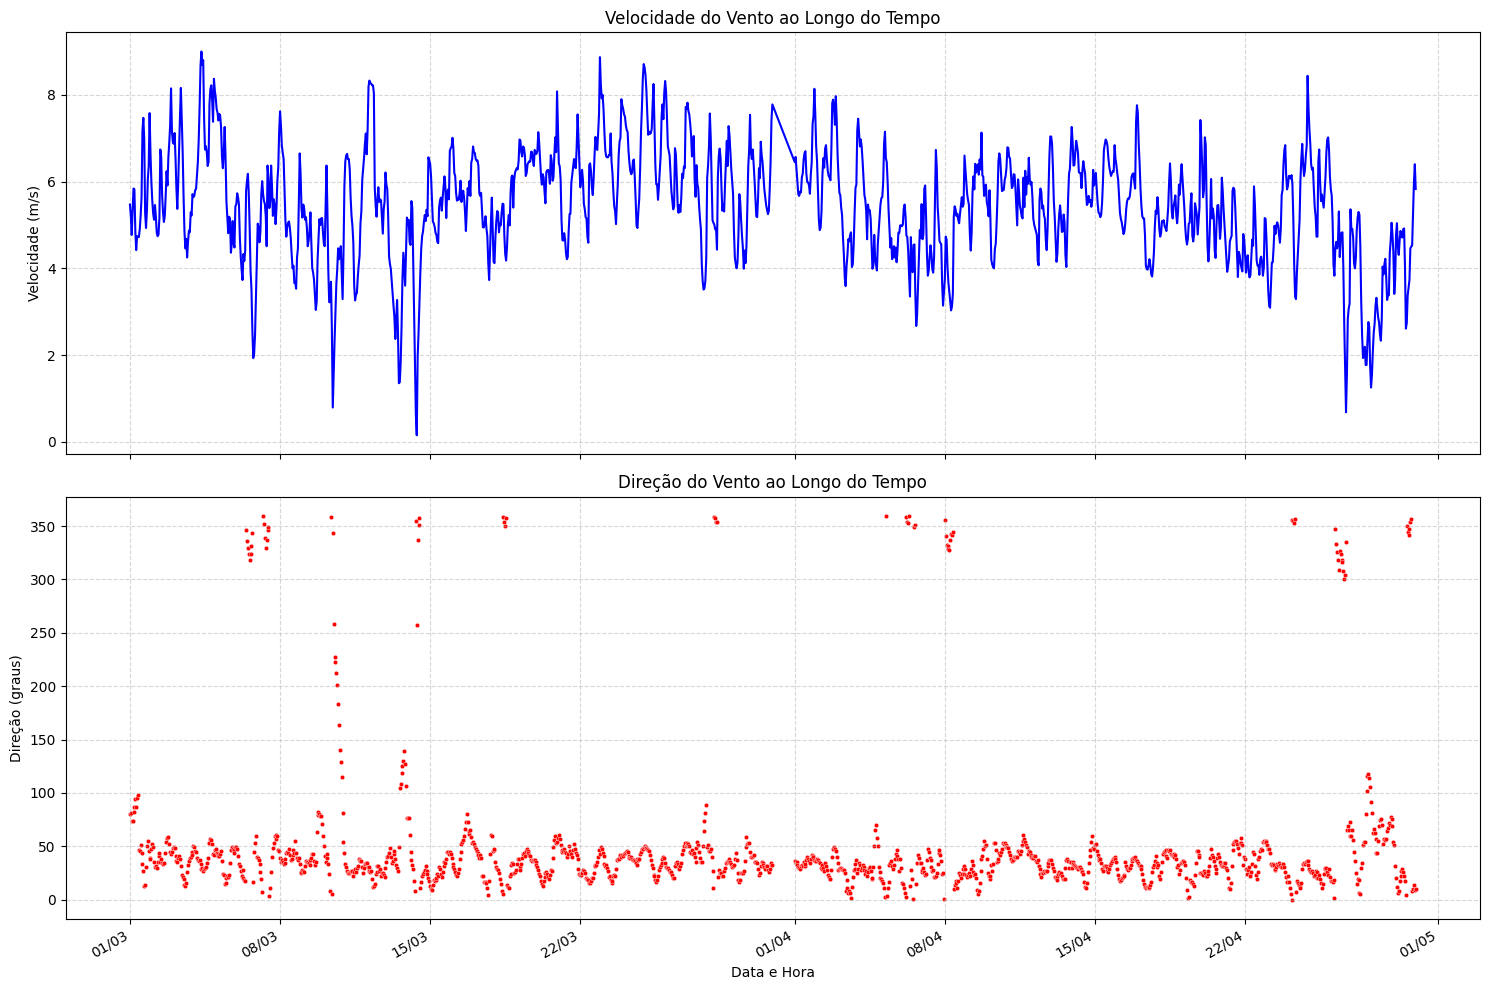

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True) # Create 2 subplots sharing the x-axis

# Plotting wind velocity (vel_ms) as a line plot
sns.lineplot(x='datetime', y='vel_ms', data=df_chu, ax=axes[0], color='blue')
axes[0].set_title('Velocidade do Vento ao Longo do Tempo')
axes[0].set_ylabel('Velocidade (m/s)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plotting wind direction (dir_deg) as a scatter plot
sns.scatterplot(x='datetime', y='dir_deg', data=df_chu, ax=axes[1], color='red', s=10)
axes[1].set_title('Direção do Vento ao Longo do Tempo')
axes[1].set_xlabel('Data e Hora')
axes[1].set_ylabel('Direção (graus)')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Format x-axis for better readability of dates
fig.autofmt_xdate()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

plt.tight_layout()
plt.show()

output_path = '/content/drive/MyDrive/Ondas/Dados/Refinados/Wind_Nov.csv'
